# Finding the Best Neighborhood in Pittsburgh
### PGHSNAP Neighborhood Census Data (2010)

**Sub-metric:** Composite Livability Score an equal-weighted average of three normalized domain scores: Transportation Access, Public Safety, and Education & Income.

A higher score means better access to transit/walkability, lower crime, and stronger economic indicators.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

## Load & Merge Data

In [2]:
FILE = 'opendata-pghsnap-neighborhood-census-data.xlsx'

transport = pd.read_excel(FILE, sheet_name='Transportation')
safety    = pd.read_excel(FILE, sheet_name='Public Safety')
edu       = pd.read_excel(FILE, sheet_name='Education & Income')

# Merge all three on Neighborhood, drop duplicate columns
df = transport.merge(safety, on='Neighborhood', suffixes=('', '_drop')) \
              .merge(edu,    on='Neighborhood', suffixes=('', '_drop'))
df = df[[c for c in df.columns if not c.endswith('_drop')]]
df = df.set_index('Neighborhood')

print(f'{df.shape[0]} neighborhoods, {df.shape[1]} columns')
df.head()

90 neighborhoods, 43 columns


,Sector #,Population (2010),Miles of Major Roads,Total Street Miles,Street Density (st. mi/area sq. mi),# Sets of Steps,# Step Treads,Res. Permit Parking Area(s),Total Working Pop. (Age 16+) (2010),Commute to Work: Drive Alone (2010),...,Edu. Attainment: Assoc./Prof. Degree (2010),Edu. Attainment: Bachelor's Degree (2010),Edu. Attainment: Postgraduate Degree (2010),1999 Median Income ('99 Dollars),2009 Median Income ('09 Dollars),1999 Median Income ('11 Dollars),2009 Med. Income ('13 Dollars),Est. Pop. for which Poverty Calc. (2010),Est. Pop. Under Poverty (2010),Est. Percent Under Poverty (2010)
Neighborhood,,,,,,,,,,,,,,,,,,,,,
Allegheny Center,3,933,2.232425,4.141467,19.721273,0,0,NaN,386,0.277202,...,0.172414,0.157635,0.037767,16964.0,20911.0,22535.000000,22792.99,954,324,0.339623
Allegheny West,3,462,1.471627,4.870843,34.544983,0,0,G,151,0.231788,...,0.066946,0.447699,0.104603,26638.0,41761.0,35385.954374,45519.49,239,12,0.050209
Allentown,6,2500,1.648451,12.325689,41.781996,12,474,NaN,824,0.469660,...,0.065934,0.056102,0.015038,22539.0,29274.0,29940.837361,31908.66,2212,630,0.284810
Arlington,7,1869,0.861571,10.734269,22.838871,13,428,NaN,673,0.739970,...,0.100649,0.071429,0.025162,27167.0,25119.0,36088.678672,27379.71,1779,361,0.202923
Arlington Heights,7,244,0.000000,1.086460,8.230760,0,0,NaN,72,0.111111,...,0.000000,0.078313,0.000000,18646.0,9417.0,24769.371021,10264.53,293,169,0.576792


## Exploratory Data Analysis

A quick look at the three domains before building the score.

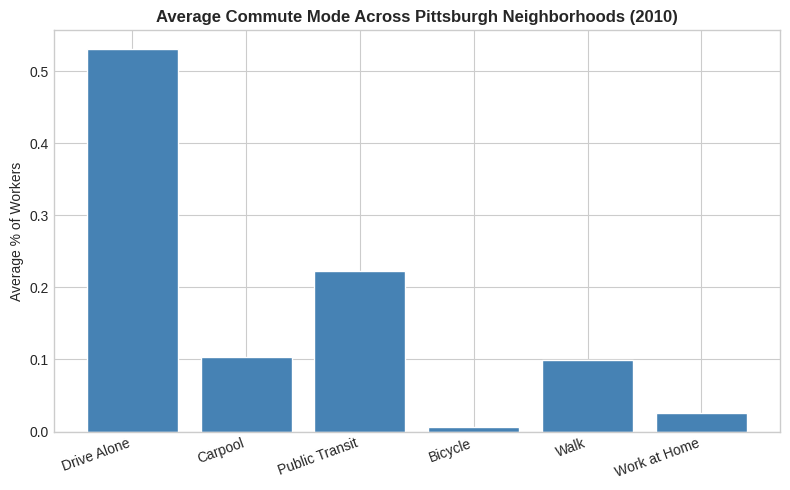

In [3]:
# Commute mode breakdown — city-wide average across neighborhoods
commute_cols = [
    'Commute to Work: Drive Alone (2010)',
    'Commute to Work: Carpool/Vanpool (2010)',
    'Commute to Work: Public Transportation (2010)',
    'Commute to Work: Bicycle (2010)',
    'Commute to Work: Walk (2010)',
    'Work at Home (2010)'
]
labels = ['Drive Alone', 'Carpool', 'Public Transit', 'Bicycle', 'Walk', 'Work at Home']

city_avg = df[commute_cols].mean()
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(labels, city_avg.values, color='steelblue', edgecolor='white')
ax.set_title('Average Commute Mode Across Pittsburgh Neighborhoods (2010)', fontweight='bold')
ax.set_ylabel('Average % of Workers')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

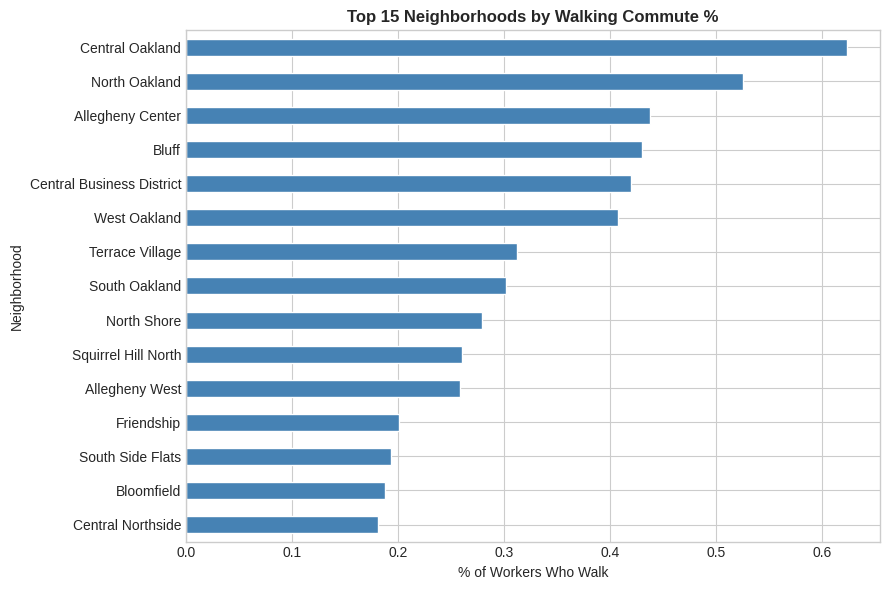

In [4]:
# Top 15 neighborhoods by walkability
walk = df['Commute to Work: Walk (2010)'].sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(9, 6))
walk.plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 15 Neighborhoods by Walking Commute %', fontweight='bold')
ax.set_xlabel('% of Workers Who Walk')
plt.tight_layout()
plt.show()

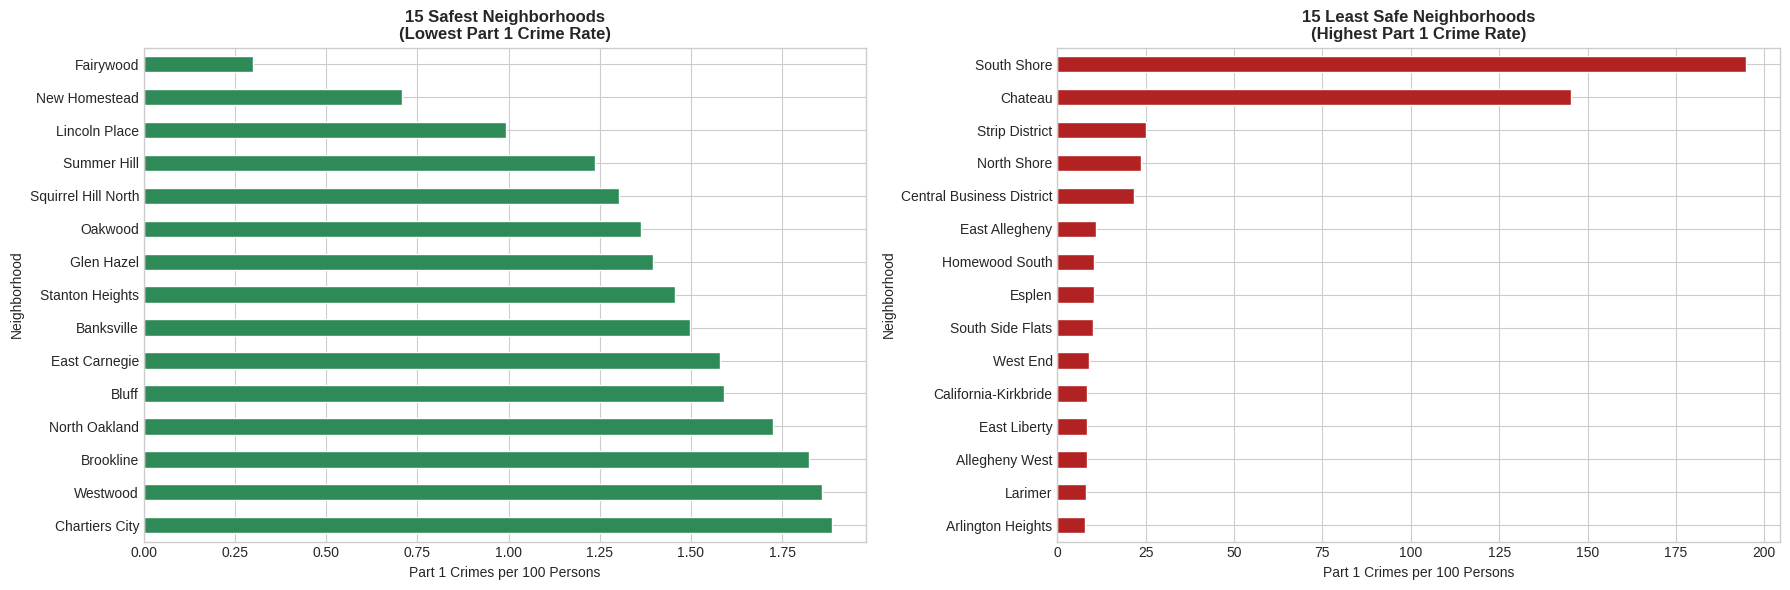

In [5]:
# Top/bottom 15 neighborhoods by crime rate
crime_col = 'Part 1 Crime per 100 Persons (2010)'
crime = df[crime_col].sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
crime.head(15).plot.barh(ax=axes[0], color='seagreen', edgecolor='white')
axes[0].set_title('15 Safest Neighborhoods\n(Lowest Part 1 Crime Rate)', fontweight='bold')
axes[0].invert_yaxis()
axes[0].set_xlabel('Part 1 Crimes per 100 Persons')

crime.tail(15).sort_values(ascending=False).plot.barh(ax=axes[1], color='firebrick', edgecolor='white')
axes[1].set_title('15 Least Safe Neighborhoods\n(Highest Part 1 Crime Rate)', fontweight='bold')
axes[1].invert_yaxis()
axes[1].set_xlabel('Part 1 Crimes per 100 Persons')
plt.tight_layout()
plt.show()

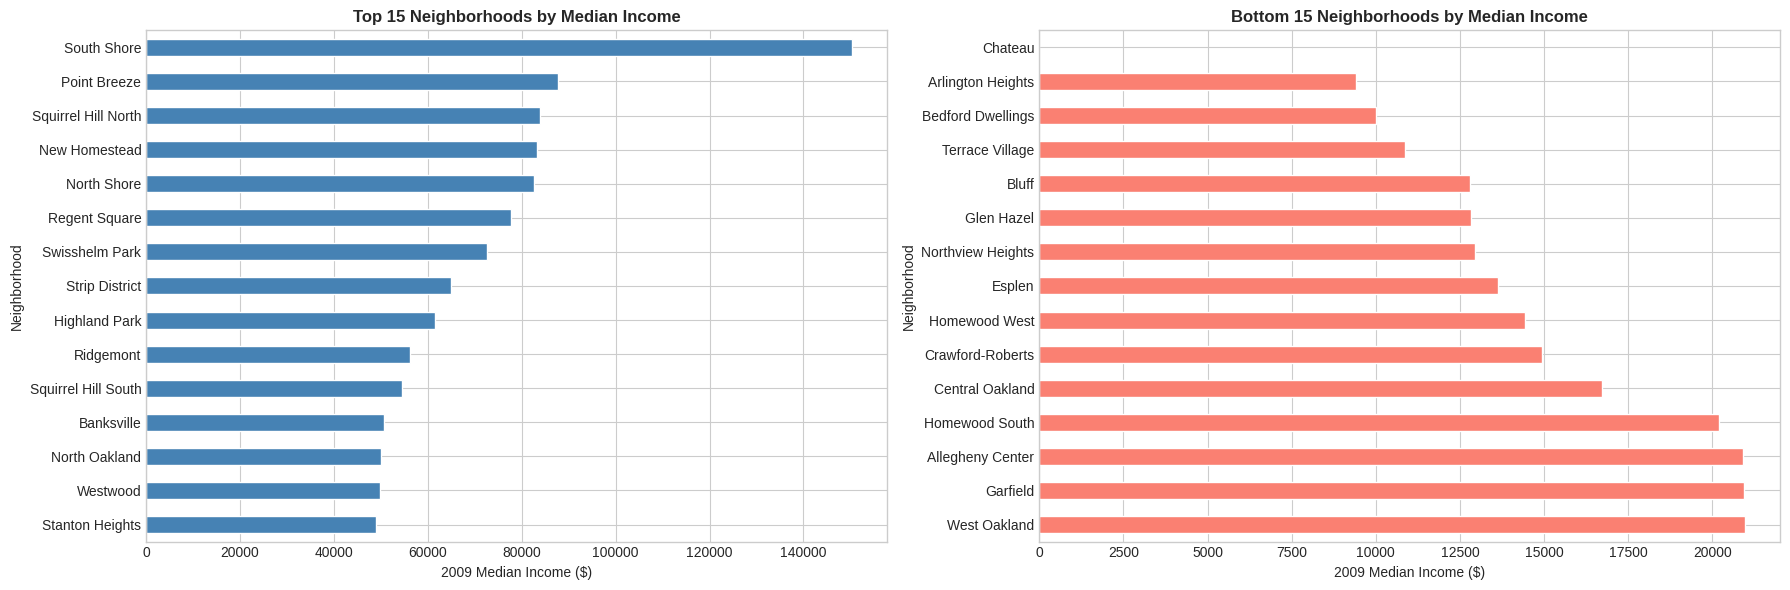

In [6]:
# Top/bottom 15 neighborhoods by median income
income_col = "2009 Median Income ('09 Dollars)"
income = df[income_col].sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
income.head(15).plot.barh(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 15 Neighborhoods by Median Income', fontweight='bold')
axes[0].invert_yaxis()
axes[0].set_xlabel('2009 Median Income ($)')

income.tail(15).sort_values().plot.barh(ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Bottom 15 Neighborhoods by Median Income', fontweight='bold')
axes[1].invert_yaxis()
axes[1].set_xlabel('2009 Median Income ($)')
plt.tight_layout()
plt.show()

## Composite Livability Score

Each variable is min-max normalized to 0–1. Variables where lower is better (crime, poverty, drive-alone rate) are inverted. The three domain scores are averaged equally.

| Domain | Variables | Direction |
|---|---|---|
| Transportation | Walk %, Transit %, Bike % | Higher = better |
| Transportation | Drive Alone % | Lower = better (inverted) |
| Public Safety | Part 1 & Part 2 Crime Rate | Lower = better (inverted) |
| Education & Income | Median Income, Bachelor's Degree % | Higher = better |
| Education & Income | % Under Poverty | Lower = better (inverted) |

In [7]:
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

# Transportation score
transport_score = (
    normalize(df['Commute to Work: Walk (2010)']) +
    normalize(df['Commute to Work: Public Transportation (2010)']) +
    normalize(df['Commute to Work: Bicycle (2010)']) +
    (1 - normalize(df['Commute to Work: Drive Alone (2010)']))
) / 4

# Safety score
safety_score = (
    (1 - normalize(df['Part 1 Crime per 100 Persons (2010)'])) +
    (1 - normalize(df['Part 2 Crime per 100 Persons (2010)']))
) / 2

# Education & Income score
edu_score = (
    normalize(df["2009 Median Income ('09 Dollars)"]) +
    normalize(df["Edu. Attainment: Bachelor's Degree (2010)"]) +
    (1 - normalize(df['Est. Percent Under Poverty (2010)']))
) / 3

# Composite
scores = pd.DataFrame({
    'Transport Score': transport_score,
    'Safety Score':    safety_score,
    'Edu/Income Score': edu_score
})
scores['Livability Score'] = scores.mean(axis=1)
scores = scores.sort_values('Livability Score', ascending=False)

scores.head(10).round(3)

,Transport Score,Safety Score,Edu/Income Score,Livability Score
Neighborhood,,,,
North Oakland,0.558,0.995,0.518,0.690
Allegheny West,0.358,0.963,0.743,0.688
Friendship,0.499,0.985,0.540,0.675
Squirrel Hill North,0.331,0.997,0.689,0.672
Bloomfield,0.504,0.981,0.516,0.667
Shadyside,0.335,0.986,0.610,0.644
Squirrel Hill South,0.300,0.994,0.619,0.637
Point Breeze,0.195,0.994,0.706,0.632
Swisshelm Park,0.216,0.994,0.682,0.631


## Results

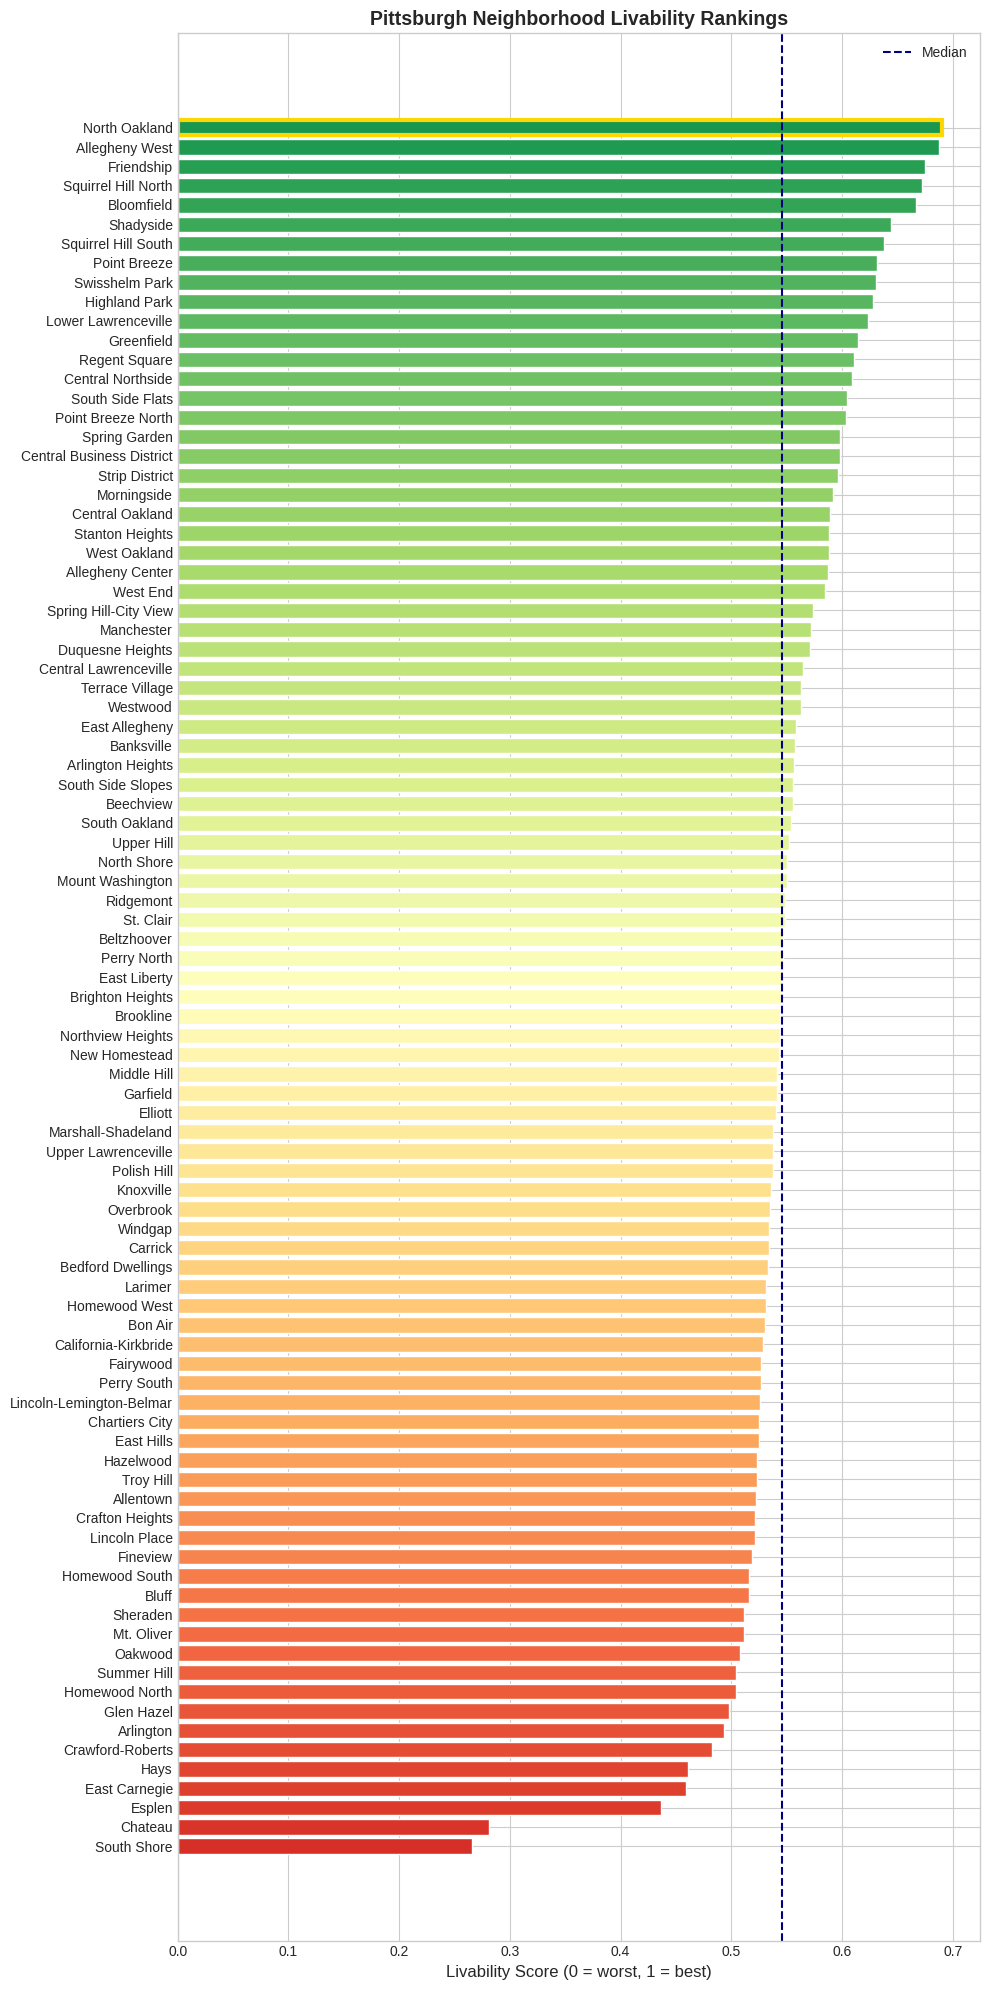

In [8]:
# Full ranking
fig, ax = plt.subplots(figsize=(10, 20))
sorted_scores = scores['Livability Score'].sort_values()
colors = cm.RdYlGn(np.linspace(0.1, 0.9, len(sorted_scores)))
bars = ax.barh(sorted_scores.index, sorted_scores.values, color=colors, edgecolor='white')

winner = scores['Livability Score'].idxmax()
for bar, name in zip(bars, sorted_scores.index):
    if name == winner:
        bar.set_edgecolor('gold')
        bar.set_linewidth(3)

ax.axvline(scores['Livability Score'].median(), color='navy', linestyle='--', linewidth=1.5, label='Median')
ax.set_xlabel('Livability Score (0 = worst, 1 = best)', fontsize=12)
ax.set_title('Pittsburgh Neighborhood Livability Rankings', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

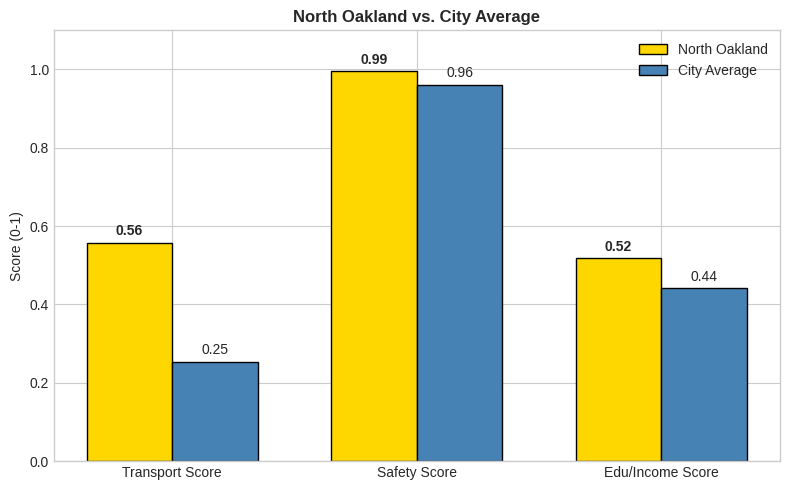

In [9]:
# Winner breakdown vs city average
domain_cols = ['Transport Score', 'Safety Score', 'Edu/Income Score']
winner_vals = scores.loc[winner, domain_cols]
city_avg    = scores[domain_cols].mean()

x = np.arange(len(domain_cols))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, winner_vals.values, w, label=winner, color='gold', edgecolor='black')
ax.bar(x + w/2, city_avg.values,    w, label='City Average', color='steelblue', edgecolor='black')
for i, (wv, cv) in enumerate(zip(winner_vals.values, city_avg.values)):
    ax.text(i - w/2, wv + 0.02, f'{wv:.2f}', ha='center', fontsize=10, fontweight='bold')
    ax.text(i + w/2, cv + 0.02, f'{cv:.2f}', ha='center', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(domain_cols)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score (0-1)')
ax.set_title(f'{winner} vs. City Average', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
winner_score = scores.loc[winner, 'Livability Score']
runner_up    = scores.index[1]
print(f'Winner:    {winner} ({winner_score:.3f})')
print(f'Runner-up: {runner_up} ({scores.loc[runner_up, "Livability Score"]:.3f})')

Winner:    North Oakland (0.690)
Runner-up: Allegheny West (0.688)


## Conclusion

The **Composite Livability Score** ranks Pittsburgh's 90 neighborhoods across three domains drawn from the 2010 PGHSNAP census data.

**Transportation Access** rewards neighborhoods where residents walk, bike, or take transit instead of driving alone. This reflects how connected and accessible a neighborhood is without a car.

**Public Safety** uses Part 1 and Part 2 crime rates per 100 residents. Both are inverted so that lower crime produces a higher score. Safety is one of the most fundamental factors in how people experience their neighborhood day to day.

**Education & Income** combines median household income, bachelor's degree attainment, and poverty rate. Together these capture the economic opportunity available to residents and the overall financial health of the neighborhood.

By this measure, North Oaklandis Pittsburgh's best neighborhood in 2010 scoring above the city average in all three domains. It isn't necessarily the richest or the safest neighborhood in isolation, but it performs consistently well across all three areas, which is what livability is really about.

**Limitations:** The data is from 2010, so it does not reflect 15 years of development and demographic change. Equal weighting across domains is one valid choice, but someone who prioritizes safety above all else might rank neighborhoods differently. The score also does not account for green space, school quality, cultural amenities, or housing affordability.